# Exploratory Data Analysis - IEEE-CIS Fraud Detection

This notebook follows the four EDA analyses from the project plan, but adapts them for the real file size.

The original plan assumed we could load the whole CSV into memory:

```python
txn = pd.read_csv(...)
idf = pd.read_csv(...)
df = txn.merge(idf, ...)
```

That is risky here because `train_transaction.csv` is large. So this notebook uses two approaches:

1. **Sample loading** for previewing the merged dataset structure.
2. **Chunk-based analysis** for full-dataset math.

The goal is not only to run code, but to understand what each EDA step is measuring and why it matters for fraud detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TXN_PATH = "../data/raw/train_transaction.csv"
ID_PATH = "../data/raw/train_identity.csv"
CHUNKSIZE = 50_000

plt.style.use("default")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

## Step 1 - Load Data Safely And Understand The Dataset

### What the project plan wanted

The HTML plan says to load transaction data, load identity data, merge them, then print:

- shape
- fraud rate

### Why we adjust it

The full transaction file is large. Loading every column and merging the full identity file inside a notebook can use too much memory.

### What we do instead

- Load only `50,000` rows for a preview.
- Merge only the sample, so we understand the combined structure.
- Use chunks to calculate the full-data row count and full-data fraud rate.

### Math

Fraud rate:

```text
fraud_rate = number_of_fraud_transactions / total_transactions
```

Here `isFraud = 1` means fraud, and `isFraud = 0` means legitimate.

In [2]:
# Sample load for preview only
txn_sample = pd.read_csv(TXN_PATH, nrows=50_000)
id_sample = pd.read_csv(ID_PATH, nrows=50_000)
df_sample = txn_sample.merge(id_sample, on="TransactionID", how="left")

print("Sample transaction shape:", txn_sample.shape)
print("Sample identity shape:", id_sample.shape)
print("Sample merged shape:", df_sample.shape)
print("Columns in merged sample:", df_sample.shape[1])
print("Sample fraud rate:", round(txn_sample["isFraud"].mean(), 4))

df_sample.head()

Sample transaction shape: (50000, 394)
Sample identity shape: (50000, 41)
Sample merged shape: (50000, 434)
Columns in merged sample: 434
Sample fraud rate: 0.0271


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,...,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,...,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# Full-data row count and fraud rate using chunks.
# We only need TransactionID and isFraud for this calculation.

total_rows = 0
fraud_rows = 0

for chunk in pd.read_csv(
    TXN_PATH,
    usecols=["TransactionID", "isFraud"],
    chunksize=CHUNKSIZE,
):
    total_rows += len(chunk)
    fraud_rows += chunk["isFraud"].sum()

legitimate_rows = total_rows - fraud_rows
fraud_rate = fraud_rows / total_rows

dataset_summary = pd.DataFrame({
    "metric": [
        "total_transactions",
        "fraud_transactions",
        "legitimate_transactions",
        "fraud_rate",
    ],
    "value": [
        total_rows,
        fraud_rows,
        legitimate_rows,
        fraud_rate,
    ],
})

dataset_summary

,metric,value
0,total_transactions,590540.0000
1,fraud_transactions,20663.0000
2,legitimate_transactions,569877.0000
3,fraud_rate,0.0350


## Step 2 - Class Imbalance Analysis

### What we are checking

Fraud datasets are usually imbalanced. That means most rows are legitimate and only a small percentage are fraud.

### Why this matters

If fraud is rare, a model can get high accuracy by predicting every transaction as legitimate. That would be useless because it catches no fraud.

### Math

Class percentage:

```text
class_percentage = class_count / total_transactions * 100
```

We calculate:

- percentage of legitimate transactions
- percentage of fraud transactions

,class_label,isFraud_value,count,percent
0,Legitimate,0,569877,96.5010
1,Fraud,1,20663,3.4990


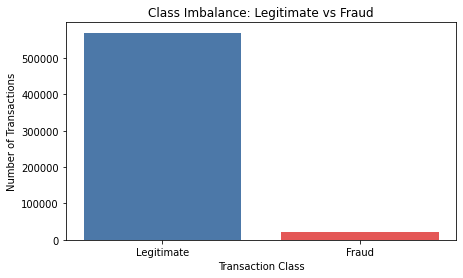

In [4]:
class_counts = pd.DataFrame({
    "class_label": ["Legitimate", "Fraud"],
    "isFraud_value": [0, 1],
    "count": [legitimate_rows, fraud_rows],
})

class_counts["percent"] = class_counts["count"] / total_rows * 100

display(class_counts)

plt.figure(figsize=(7, 4))
plt.bar(class_counts["class_label"], class_counts["count"], color=["#4C78A8", "#E45756"])
plt.title("Class Imbalance: Legitimate vs Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

## Step 3 - Fraud Rate By Hour

### What we are checking

The project plan suggests that fraud may change by time of day.

The dataset does not have a real timestamp column. It has `TransactionDT`, which is a time delta in seconds. We convert it into an hour-like feature.

### Feature math

```text
hour = floor(TransactionDT / 3600) % 24
```

### Fraud-rate math per hour

```text
fraud_rate_for_hour = fraud_transactions_in_that_hour / total_transactions_in_that_hour
```

### Why this matters

If fraud is higher during certain hours, we can create useful model features:

- `hour`
- `is_late_night`

,hour,transactions,frauds,fraud_rate
0,0,37795,1186,0.0314
1,1,32797,1027,0.0313
2,2,26732,1002,0.0375
3,3,20802,797,0.0383
4,4,14839,770,0.0519
5,5,9701,682,0.0703
6,6,6007,467,0.0777
7,7,3704,393,0.1061
8,8,2591,241,0.0930
9,9,2479,223,0.0900


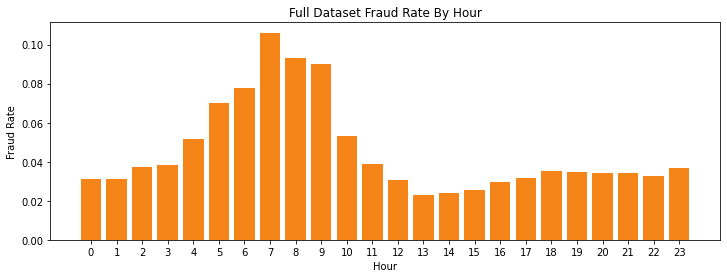

In [5]:
hour_counts = pd.Series(0, index=range(24), dtype="int64")
hour_frauds = pd.Series(0, index=range(24), dtype="int64")

for chunk in pd.read_csv(
    TXN_PATH,
    usecols=["TransactionDT", "isFraud"],
    chunksize=CHUNKSIZE,
):
    hour = (chunk["TransactionDT"] // 3600).astype(int) % 24

    counts = hour.value_counts().reindex(range(24), fill_value=0)
    frauds = chunk.groupby(hour)["isFraud"].sum().reindex(range(24), fill_value=0)

    hour_counts += counts.astype("int64")
    hour_frauds += frauds.astype("int64")

hour_eda = pd.DataFrame({
    "hour": range(24),
    "transactions": hour_counts.values,
    "frauds": hour_frauds.values,
})
hour_eda["fraud_rate"] = hour_eda["frauds"] / hour_eda["transactions"]

display(hour_eda)

plt.figure(figsize=(12, 4))
plt.bar(hour_eda["hour"], hour_eda["fraud_rate"], color="#F58518")
plt.title("Full Dataset Fraud Rate By Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.xticks(range(24))
plt.show()

## Step 4 - Fraud Rate By Transaction Amount Bucket

### What we are checking

The project plan asks whether high-value transactions have a different fraud rate.

Instead of looking at every individual amount, we group transaction amounts into buckets.

### Bucket logic

We use these buckets:

- `0-50`
- `50-200`
- `200-500`
- `500-2000`
- `2000+`

### Fraud-rate math per bucket

```text
fraud_rate_for_bucket = fraud_transactions_in_bucket / total_transactions_in_bucket
```

### Why this matters

If fraud rate changes by amount bucket, we can create useful model features:

- `log_amount`
- `is_high_value`
- `amount_rounded`

,amount_bucket,transactions,frauds,fraud_rate
0,0-50,204524,7833,0.0383
1,50-200,292136,8687,0.0297
2,200-500,71001,3135,0.0442
3,500-2000,20843,966,0.0463
4,2000+,2036,42,0.0206


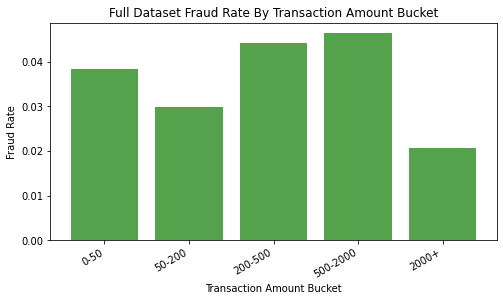

In [6]:
amount_bins = [0, 50, 200, 500, 2000, 100000]
amount_labels = ["0-50", "50-200", "200-500", "500-2000", "2000+"]

bucket_counts = pd.Series(0, index=amount_labels, dtype="int64")
bucket_frauds = pd.Series(0, index=amount_labels, dtype="int64")

for chunk in pd.read_csv(
    TXN_PATH,
    usecols=["TransactionAmt", "isFraud"],
    chunksize=CHUNKSIZE,
):
    amount_bucket = pd.cut(
        chunk["TransactionAmt"],
        bins=amount_bins,
        labels=amount_labels,
        include_lowest=True,
    )

    counts = amount_bucket.value_counts().reindex(amount_labels, fill_value=0)
    frauds = chunk.groupby(amount_bucket, observed=False)["isFraud"].sum().reindex(amount_labels, fill_value=0)

    bucket_counts += counts.astype("int64")
    bucket_frauds += frauds.astype("int64")

amount_eda = pd.DataFrame({
    "amount_bucket": amount_labels,
    "transactions": bucket_counts.values,
    "frauds": bucket_frauds.values,
})
amount_eda["fraud_rate"] = amount_eda["frauds"] / amount_eda["transactions"]

display(amount_eda)

plt.figure(figsize=(8, 4))
plt.bar(amount_eda["amount_bucket"], amount_eda["fraud_rate"], color="#54A24B")
plt.title("Full Dataset Fraud Rate By Transaction Amount Bucket")
plt.xlabel("Transaction Amount Bucket")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30, ha="right")
plt.show()

## Final EDA Interpretation

### What we learned from these four analyses

Use the displayed tables and charts above to write your findings in your own words.

Focus on these conclusions:

1. **Class imbalance**
   - Fraud is a small percentage of all transactions.
   - Model evaluation should focus on recall, precision, F1, and AUC-PR, not plain accuracy.

2. **Time behavior**
   - Fraud rate can vary by hour.
   - Time-derived features may help the model.

3. **Amount behavior**
   - Fraud rate can vary across amount buckets.
   - Amount-derived features may help the model.

4. **Data-size strategy**
   - Use samples for exploration and display.
   - Use chunks for full-data calculations.
   - Use scripts, not notebooks, for heavy full-data preprocessing.

### Next step after EDA

Move the useful feature ideas into `src/data/preprocess.py`, especially:

- `hour`
- `is_late_night`
- `log_amount`
- `is_high_value`
- `amount_rounded`